## A Simple Example

In [1]:
# %matplotlib inline

import torch

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

In [2]:
a = torch.linspace(0.0, 2.0 * math.pi, steps=25, requires_grad=True)
print(a)

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)


In [3]:
b = torch.sin(a)
print(b)

tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


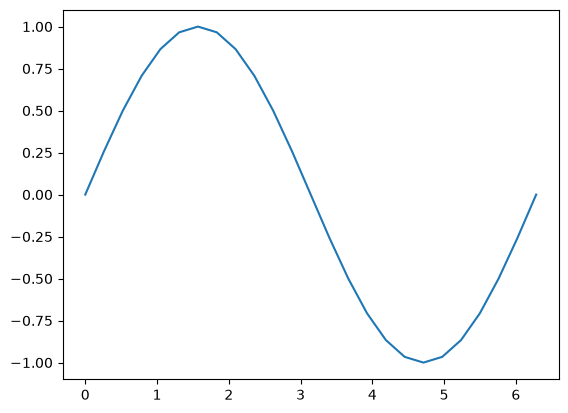

In [4]:
plt.plot(a.detach(), b.detach())

In [5]:
c = 2 * b
print(c)

d = c + 1
print(d)

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)


In [6]:
out = d.sum()
print(out)

tensor(25., grad_fn=<SumBackward0>)


In [7]:
print("d:")
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(
    d.grad_fn.next_functions[0][0]
    .next_functions[0][0]
    .next_functions[0][0]
    .next_functions
)

print("\nc:")
print(c.grad_fn)

print("\nb:")
print(b.grad_fn)

print("\na:")
print(a.grad_fn)

d:
((<MulBackward0 object at 0x10e2efa00>, 0), (None, 0))
((<SinBackward0 object at 0x107897a00>, 0), (None, 0))
((<AccumulateGrad object at 0x10e1f2080>, 0),)
()

c:

b:

a:
None


In [8]:
out.backward()
print(a.grad)

tensor([ 2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,  1.0000e+00,
         5.1764e-01, -8.7423e-08, -5.1764e-01, -1.0000e+00, -1.4142e+00,
        -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00, -1.7321e+00,
        -1.4142e+00, -1.0000e+00, -5.1764e-01,  2.3850e-08,  5.1764e-01,
         1.0000e+00,  1.4142e+00,  1.7321e+00,  1.9319e+00,  2.0000e+00])


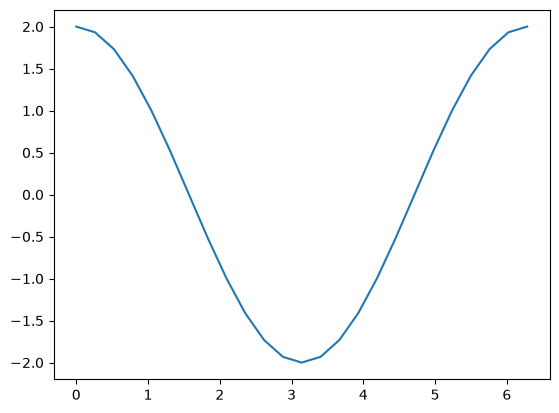

In [9]:
plt.plot(a.detach(), a.grad.detach())

In [10]:
a = torch.linspace(0.0, 2.0 * math.pi, steps=25, requires_grad=True)
b = torch.sin(a)
c = 2 * b
d = c + 1
out = d.sum()

## Autograd in Training

In [11]:
BATCH_SIZE = 16
DIM_IN = 1000
HIDDEN_SIZE = 100
DIM_OUT = 10


class TinyModel(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE)
        self.relu = torch.nn.ReLU()
        self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=True)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=True)

model = TinyModel()

In [12]:
from torchinfo import summary

summary(model, (BATCH_SIZE, DIM_IN), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
TinyModel                                [16, 1000]                [16, 10]                  --
├─Linear: 1-1                            [16, 1000]                [16, 100]                 100,100
├─ReLU: 1-2                              [16, 100]                 [16, 100]                 --
├─Linear: 1-3                            [16, 100]                 [16, 10]                  1,010
Total params: 101,110
Trainable params: 101,110
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.62
Input size (MB): 0.06
Forward/backward pass size (MB): 0.01
Params size (MB): 0.40
Estimated Total Size (MB): 0.48

In [13]:
print(model.layer2.weight.shape)
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad)

torch.Size([10, 100])
tensor([ 0.0953, -0.0404, -0.0803, -0.0594, -0.0967, -0.0114, -0.0114, -0.0185,
        -0.0828, -0.0032], grad_fn=<SliceBackward0>)
None


In [14]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

prediction = model(some_input)
print(f"{some_input[0][:5]=}")
print(f"{ideal_output[0][:5]=}")
print(f"{prediction[0][:5]=}")

some_input[0][:5]=tensor([-1.1530,  1.3225,  0.0292, -0.5533, -0.9328], grad_fn=<SliceBackward0>)
ideal_output[0][:5]=tensor([ 1.7199,  0.4626,  1.1029,  0.5081, -0.0796], grad_fn=<SliceBackward0>)
prediction[0][:5]=tensor([-0.3042,  0.2707, -0.3182, -0.0859,  0.2019], grad_fn=<SliceBackward0>)


In [15]:
loss = (ideal_output - prediction).pow(2).sum()
print(loss)

tensor(151.7700, grad_fn=<SumBackward0>)


In [16]:
loss.backward()
print(model.layer2.weight[0][0:10])

assert model.layer2.weight.grad is not None
print(model.layer2.weight.grad[0][0:10])

tensor([ 0.0953, -0.0404, -0.0803, -0.0594, -0.0967, -0.0114, -0.0114, -0.0185,
        -0.0828, -0.0032], grad_fn=<SliceBackward0>)
tensor([-0.3454, -2.4069, -1.9155, -1.6935, -0.2950, -2.3237, -3.7357, -6.8691,
        -4.3718,  2.0327])


In [17]:
optimizer.step()
print(model.layer2.weight[0][0:10])

assert model.layer2.weight.grad is not None
print(model.layer2.weight.grad[0][0:10])

tensor([ 0.0956, -0.0380, -0.0784, -0.0577, -0.0965, -0.0091, -0.0077, -0.0117,
        -0.0784, -0.0052], grad_fn=<SliceBackward0>)
tensor([-0.3454, -2.4069, -1.9155, -1.6935, -0.2950, -2.3237, -3.7357, -6.8691,
        -4.3718,  2.0327])


In [18]:
assert model.layer2.weight.grad is not None
print(model.layer2.weight.grad[0][0:10])

for i in range(0, 5):
    prediction = model(some_input)
    loss = (ideal_output - prediction).pow(2).sum()
    loss.backward()

print(model.layer2.weight.grad[0][0:10])

optimizer.zero_grad(set_to_none=False)

print(model.layer2.weight.grad[0][0:10])

tensor([-0.3454, -2.4069, -1.9155, -1.6935, -0.2950, -2.3237, -3.7357, -6.8691,
        -4.3718,  2.0327])
tensor([ -5.7116,  -9.6469,   3.4542,  -3.0049,  12.9478,   1.1384, -12.7064,
        -18.8942,  -5.7905,   8.1632])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## Turning Autograd Off and On

In [19]:
a = torch.ones(2, 3, requires_grad=True)
print(a)

b1 = 2 * a
print(b1)

a.requires_grad = False
b2 = 2 * a
print(b2)

print(a)
print(b1)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)


In [20]:
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = a + b
print(c1)

with torch.no_grad():
    c2 = a + b

print(c2)

c3 = a * b
print(c3)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


In [21]:
def add_tensors1(x, y):
    return x + y


@torch.no_grad()
def add_tensors2(x, y):
    return x + y


a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = add_tensors1(a, b)
print(c1)

c2 = add_tensors2(a, b)
print(c2)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [22]:
x = torch.rand(5, requires_grad=True)
y = x.detach()

print(x)
print(y)

tensor([0.7991, 0.1260, 0.0607, 0.4462, 0.3042], requires_grad=True)
tensor([0.7991, 0.1260, 0.0607, 0.4462, 0.3042])


## Autograd and In-place Operations

In [23]:
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
a.sin_()

RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.

### Autograd Profiler

In [ ]:
device = torch.device("cpu")
run_on_gpu = False
if torch.cuda.is_available():
    device = torch.device("cuda")
    run_on_gpu = True

x = torch.randn(2, 3, requires_grad=True)
y = torch.rand(2, 3, requires_grad=True)
z = torch.ones(2, 3, requires_grad=True)

with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
    for _ in range(1000):
        z = (z / x) * y

assert prf is not None
print(prf.key_averages().table(sort_by="self_cpu_time_total"))

-------------  ------------  ------------  ------------  ------------  ------------  ------------  
         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
    aten::mul        53.73%       2.596ms        53.73%       2.596ms       2.596us          1000  
    aten::div        46.27%       2.236ms        46.27%       2.236ms       2.236us          1000  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 4.832ms



USDT:2026-08-19 17:24:40 78805:19349210 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-19 17:24:40 78805:19349210 SyncActivityProfilerHandler.cpp:59] profiler_stop


## Advanced Topic: More Autograd Detail and the High-Level API

In [27]:
x = torch.randn(3, requires_grad=True)
print(x)

y = x * 2
while y.data.norm() < 1000:
    y = y * 2

print(y)

tensor([ 2.1797, -0.4661, -0.0093], requires_grad=True)
tensor([1116.0288, -238.6594,   -4.7484], grad_fn=<MulBackward0>)


In [28]:
y.backward()

RuntimeError: grad can be implicitly created only for scalar outputs

v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)  # stand-in for gradients
y.backward(v)

print(x.grad)

### The High-Level API

In [32]:
def exp_adder(x1, x2):
    return 2 * x1.exp() + 3 * x2


inputs = (torch.rand(1), torch.rand(1))
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.3077]), tensor([0.8047]))


(tensor([[2.7206]]), tensor([[3.]]))

In [33]:
inputs = (torch.rand(3), torch.rand(3))  # arguments for the function
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.4063, 0.4083, 0.5302]), tensor([0.0136, 0.2395, 0.7134]))


(tensor([[3.0024, 0.0000, 0.0000],
         [0.0000, 3.0085, 0.0000],
         [0.0000, 0.0000, 3.3985]]),
 tensor([[3., 0., 0.],
         [0., 3., 0.],
         [0., 0., 3.]]))

In [34]:
def do_some_doubling(x):
    y = x * 2
    while y.data.norm() < 1000:
        y = y * 2
    return y


inputs = torch.randn(3)
my_gradients = torch.tensor([0.1, 1.0, 0.0001])
torch.autograd.functional.vjp(do_some_doubling, inputs, v=my_gradients)

(tensor([667.9619, 590.1995, 947.0195]),
 tensor([1.0240e+02, 1.0240e+03, 1.0240e-01]))